<a href="https://colab.research.google.com/github/Maryam-Asif/Assignment-/blob/main/Copy_of_Sample_Time_Series_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES
# TO THE CORRECT LOCATION (/kaggle/input) IN YOUR NOTEBOOK,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

import os
import sys
from tempfile import NamedTemporaryFile
from urllib.request import urlopen
from urllib.parse import unquote, urlparse
from urllib.error import HTTPError
from zipfile import ZipFile
import tarfile
import shutil

CHUNK_SIZE = 40960
DATA_SOURCE_MAPPING = 'air-passenger-data-for-time-series-analysis:https%3A%2F%2Fstorage.googleapis.com%2Fkaggle-data-sets%2F1516462%2F2504188%2Fbundle%2Farchive.zip%3FX-Goog-Algorithm%3DGOOG4-RSA-SHA256%26X-Goog-Credential%3Dgcp-kaggle-com%2540kaggle-161607.iam.gserviceaccount.com%252F20240918%252Fauto%252Fstorage%252Fgoog4_request%26X-Goog-Date%3D20240918T075204Z%26X-Goog-Expires%3D259200%26X-Goog-SignedHeaders%3Dhost%26X-Goog-Signature%3Da4d78fda541008f4faf5069c03db4f6cce906aaa0905c5977687b379ec479ed1dc512ac54839611ca78dc85fbe670925016f949392c84fcaccb5dfb780a7d56252e2ac492459ed56827674786ad09bbf34fa38d8a7a3d28bb67dc29ca0bff7aba7179adc8792960a04457a4e6f36a23764ac151ba84527f1854c7fa75080ae59dcbf07e45891705172e4dcf03e2790b9ef8ffcd7a0c092bb6d2a92db8d3937755916cbaaa441bdedc63f5af4f4ca57d54e39f28290abacdab259d0a13ee7163e7a7a152be8ccb55b645aeb2903046fe9eabafa49000de93e1e6fe980c129252fa7fd894e3eb67765d50a9a8698a2817c993e0f4dfecd3185c615ba9cfd2c8e11'

KAGGLE_INPUT_PATH='/kaggle/input'
KAGGLE_WORKING_PATH='/kaggle/working'
KAGGLE_SYMLINK='kaggle'

!umount /kaggle/input/ 2> /dev/null
shutil.rmtree('/kaggle/input', ignore_errors=True)
os.makedirs(KAGGLE_INPUT_PATH, 0o777, exist_ok=True)
os.makedirs(KAGGLE_WORKING_PATH, 0o777, exist_ok=True)

try:
  os.symlink(KAGGLE_INPUT_PATH, os.path.join("..", 'input'), target_is_directory=True)
except FileExistsError:
  pass
try:
  os.symlink(KAGGLE_WORKING_PATH, os.path.join("..", 'working'), target_is_directory=True)
except FileExistsError:
  pass

for data_source_mapping in DATA_SOURCE_MAPPING.split(','):
    directory, download_url_encoded = data_source_mapping.split(':')
    download_url = unquote(download_url_encoded)
    filename = urlparse(download_url).path
    destination_path = os.path.join(KAGGLE_INPUT_PATH, directory)
    try:
        with urlopen(download_url) as fileres, NamedTemporaryFile() as tfile:
            total_length = fileres.headers['content-length']
            print(f'Downloading {directory}, {total_length} bytes compressed')
            dl = 0
            data = fileres.read(CHUNK_SIZE)
            while len(data) > 0:
                dl += len(data)
                tfile.write(data)
                done = int(50 * dl / int(total_length))
                sys.stdout.write(f"\r[{'=' * done}{' ' * (50-done)}] {dl} bytes downloaded")
                sys.stdout.flush()
                data = fileres.read(CHUNK_SIZE)
            if filename.endswith('.zip'):
              with ZipFile(tfile) as zfile:
                zfile.extractall(destination_path)
            else:
              with tarfile.open(tfile.name) as tarfile:
                tarfile.extractall(destination_path)
            print(f'\nDownloaded and uncompressed: {directory}')
    except HTTPError as e:
        print(f'Failed to load (likely expired) {download_url} to path {destination_path}')
        continue
    except OSError as e:
        print(f'Failed to load {download_url} to path {destination_path}')
        continue

print('Data source import complete.')


[==================================================] 764 bytes downloaded
Downloaded and uncompressed: air-passenger-data-for-time-series-analysis
Data source import complete.


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/air-passenger-data-for-time-series-analysis/AirPassengers.csv


In [ ]:
import os
os.getcwd()

'/content'

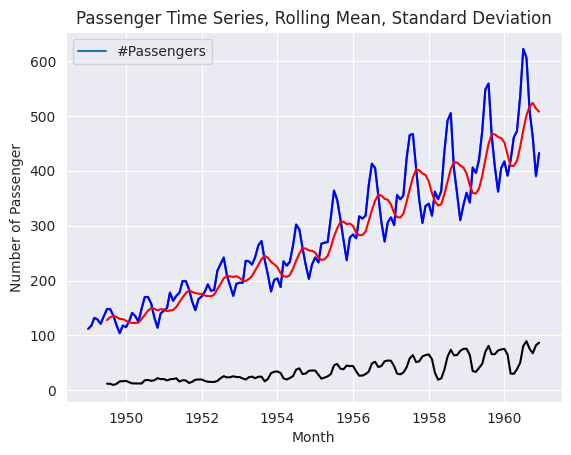

Dickey Fuller Test Ouput : 
        Values              Metric
0    0.815369          Test Stats
1    0.991880              pvalue
2   13.000000            NoofLags
3  130.000000             NoofObs
4   -3.481682   criticalvalue(1%)
5   -2.884042   criticalvalue(5%)
6   -2.578770  criticalvalue(10%)


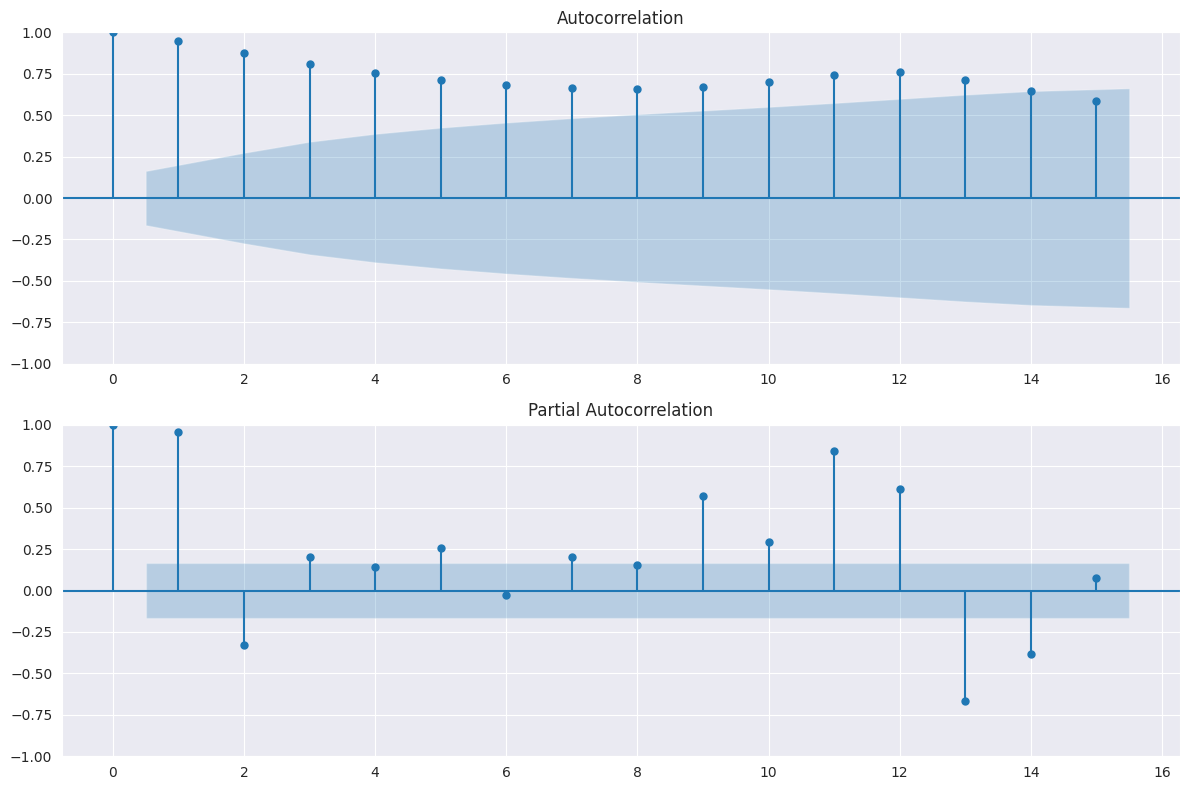

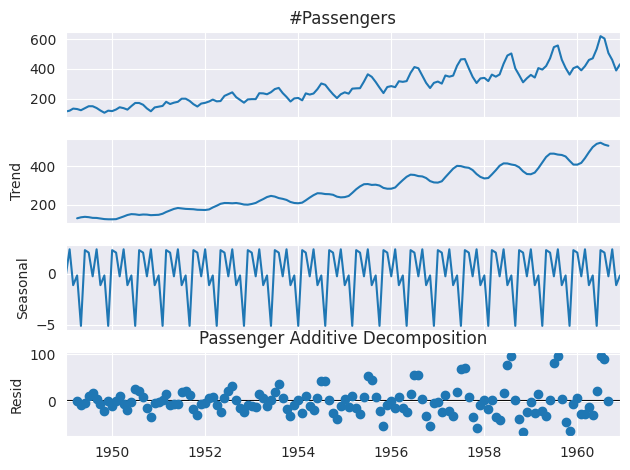

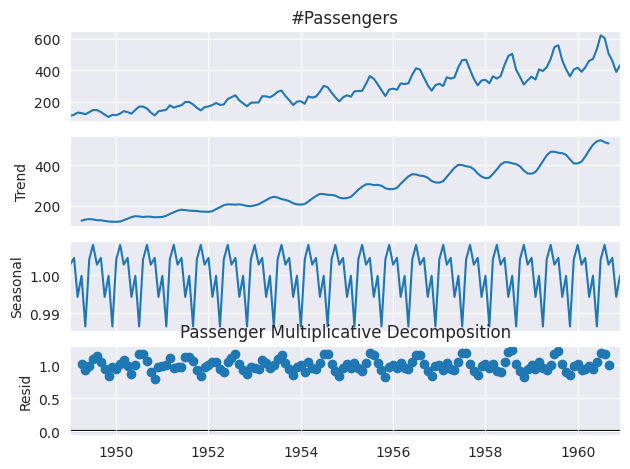

Model Summary Normal:
                                SARIMAX Results                                
Dep. Variable:            #Passengers   No. Observations:                  144
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -694.341
Date:                Fri, 20 Sep 2024   AIC                           1394.683
Time:                        07:23:06   BIC                           1403.571
Sample:                    01-01-1949   HQIC                          1398.294
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4742      0.123     -3.847      0.000      -0.716      -0.233
ma.L1          0.8635      0.078     11.051      0.000       0.710       1.017
sigma2       961.9270    107.

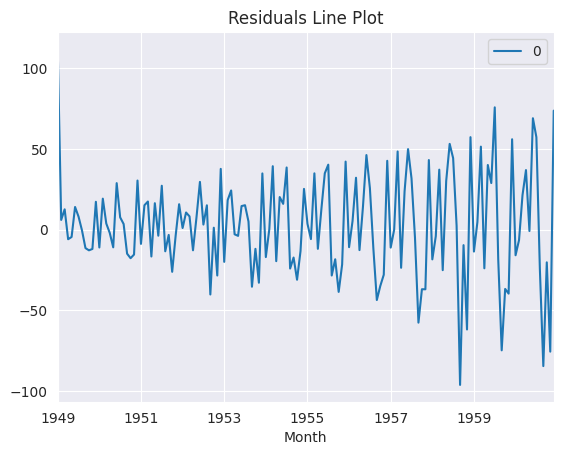

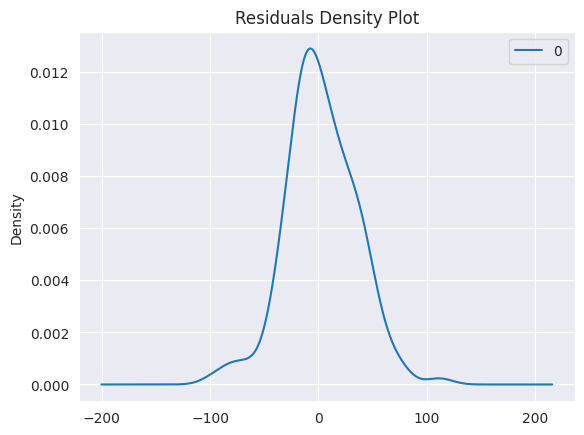

                0
count  144.000000
mean     2.705411
std     32.293238
min    -96.360708
25%    -16.812276
50%      0.056039
75%     24.475020
max    112.000000
predicted=261.804211,expected=306.000000
predicted=323.316247,expected=315.000000
predicted=312.026949,expected=301.000000
predicted=296.769588,expected=356.000000
predicted=379.173677,expected=348.000000
predicted=338.681108,expected=355.000000
predicted=359.812133,expected=422.000000
predicted=444.546923,expected=465.000000
predicted=472.742800,expected=467.000000
predicted=464.696390,expected=404.000000
predicted=379.020192,expected=347.000000
predicted=333.546845,expected=305.000000
predicted=291.870881,expected=336.000000
predicted=354.843332,expected=340.000000
predicted=334.176697,expected=318.000000
predicted=311.245279,expected=362.000000
predicted=383.829359,expected=348.000000
predicted=334.970416,expected=363.000000
predicted=372.390997,expected=435.000000
predicted=460.065180,expected=491.000000
predicted=504.4247

In [ ]:
import pandas as pd
import os
import seaborn as sbrn
import matplotlib.pyplot as plt
from matplotlib import pyplot
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tools.sm_exceptions import  ValueWarning
warnings.simplefilter('ignore', ValueWarning)
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error
from math import sqrt
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf


#os.chdir('/kaggle/working')
Data=pd.read_csv('/kaggle/input/air-passenger-data-for-time-series-analysis/AirPassengers.csv')
#print(Data.to_string)

# Convert the Month column into a Datetime Object

Data['Month']=pd.to_datetime(Data['Month'],format='%Y-%m')
#print(Data.to_string)

# Convert the Date column into Index to allow us to work with some packages later

Data.index=Data['Month']
del Data['Month']
#print(Data.to_string)

# Lets look at Data using Seaborn Plot
sbrn.set_style('darkgrid')
sbrn.lineplot(Data)
plt.ylabel('Number of Passenger')
#plt.show()

# Plot original Data with rolling 7 month mean and Std Dev
rolling_mean=Data.rolling(7).mean()
rolling_std=Data.rolling(7).std()

plt.plot(Data,color='blue',label="Original passenger Data")
plt.plot(rolling_mean,color='red',label="Rolling Mean Passenger Number")
plt.plot(rolling_std,color='black',label="Rolling Std Passenger Number")
plt.title("Passenger Time Series, Rolling Mean, Standard Deviation")
plt.show()

# Check for Stationarity # Stationary time series will not have any trends or Seasonality
# Check for stationarity using Dickey Fuller test and Hypothesis
# Null Hypo # No Stationarity , Alt Hypo # There is stationarity

# If P value > .05 then data is not Stationary

DicFuller=adfuller(Data,autolag='AIC')
#print(DicFuller)
Output_DFull=pd.DataFrame({"Values":[DicFuller[0],DicFuller[1],DicFuller[2],DicFuller[3],DicFuller[4]['1%'],DicFuller[4]['5%'],DicFuller[4]['10%']],
'Metric':['Test Stats','pvalue','NoofLags','NoofObs','criticalvalue(1%)','criticalvalue(5%)','criticalvalue(10%)']})
print('Dickey Fuller Test Ouput : \n',Output_DFull)


#Check for ACF : Auto correlation for MA &
# PACF  PartialAutoCorrelation of Data on different timeframes for RA components

lag_acf = 15
lag_pacf = 15
height = 4
width = 12

f, ax = plt.subplots(nrows=2, ncols=1, figsize=(width, 2*height))
plot_acf(Data['#Passengers'],lags=lag_acf, ax=ax[0])
plot_pacf(Data['#Passengers'],lags=lag_pacf, ax=ax[1], method='ols')
plt.tight_layout()
plt.show()

# Decompose the data to verify randomness, Trend, Seasonality

decompose1=seasonal_decompose(Data['#Passengers'],model='additive',period=7)
decompose1.plot()
plt.title("Passenger Additive Decomposition")
decompose2=seasonal_decompose(Data['#Passengers'],model='multiplicative',period=7)
decompose2.plot()
plt.title("Passenger Multiplicative Decomposition")
plt.show()

# Build a ARIMA Model
# For Non-Seasonal Data p=1,d=1,Q=0/1
#model=ARIMA(Data['#Passengers'],order=(1,1,1))
#X=Data['#Passengers']
log_X=np.log(Data['#Passengers'])
#print(X.head)
#print(log_X.head)

model=ARIMA(Data['#Passengers'],order=(1,1,1))
model_fit=model.fit()
print('Model Summary Normal:\n',model_fit.summary())

model2=ARIMA(log_X,order=(1,1,1))
model2_fit=model2.fit()
print('Model Summary LogNormal:\n',model2_fit.summary())

# Line Plot of residuals
residuals=pd.DataFrame(model_fit.resid)
residuals.plot()
plt.title('Residuals Line Plot')
plt.show()

# density plot of residuals
residuals.plot(kind='kde')
plt.title('Residuals Density Plot')
plt.show()
# summary stats of residuals
print(residuals.describe())

# How to Make ARIMA forecasts
X=Data['#Passengers']
Size=int(len(X)*0.66)
train,test=X[0:Size],X[Size:len(X)]
history=[x for x in train]
prediction=list()
# Walk-Forward Validaiton
for t in range(len(test)):
    model=ARIMA(history,order=(0,1,1))
    model_fit=model.fit()
    output=model_fit.forecast()
    yhat=output[0]
    prediction.append(yhat)
    obs=test[t]
    history.append(obs)
    print('predicted=%f,expected=%f' %(yhat,obs))

#evaluate forecasts, Goodness of Fit
rmse=sqrt(mean_squared_error(test,prediction))
print('Test RMSE=%f',rmse)

mpe=mean_absolute_percentage_error(test,prediction)
print('Test mpe=%f',mpe)


# Log Transformed Forecast

model2=ARIMA(log_X,order=(1,1,1))
model2_fit=model2.fit()
print('Model Summary LogNormal:\n',model2_fit.summary())

# How to Make ARIMA forecasts
X=Data['#Passengers']
Size=int(len(X)*0.66)
train,test=X[0:Size],X[Size:len(X)]
history=[x for x in train]
prediction=list()
# Walk-Forward Validaiton
for t in range(len(test)):
    model=ARIMA(np.log(history),order=(0,1,1))
    model_fit=model.fit()
    output=model_fit.forecast()
    yhat=output[0]
    prediction.append(yhat)
    obs=test[t]
    history.append(obs)
    print('predicted=%f,expected=%f' %(yhat,obs))

#evaluate forecasts, Goodness of Fit
rmse=sqrt(mean_squared_error(test,prediction))
print('Test RMSE=%f',rmse)

mpe=mean_absolute_percentage_error(test,prediction)
print('Test mpe=%f',mpe)

In [ ]:
!pip install tslearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 7.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from tslearn.metrics import dtw  # If using DTW for similarity

In [ ]:
# Load data
Data=pd.read_csv('/kaggle/input/air-passenger-data-for-time-series-analysis/AirPassengers.csv')


In [ ]:
import pandas as pd

# Load the dataset
data = pd.read_csv('/kaggle/input/air-passenger-data-for-time-series-analysis/AirPassengers.csv')
data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)
time_series = data['#Passengers']

In [ ]:
!pip install fastdtw

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fastdtw: filename=fastdtw-0.3.4-cp310-cp310-linux_x86_64.whl size=512544 sha256=b4539d47548a8a7a28665b446c3ac68895750d018573f3848dd3e4f2aac4c1b1
  Stored in directory: /root/.cache/pip/wheels/73/c8/f7/c25448dab74c3acf4848bc25d513c736bb93910277e1528ef4
Successfully built fastdtw


In [ ]:
import numpy as np
from scipy.spatial.distance import euclidean
from fastdtw import fastdtw
import networkx as nx

In [ ]:
# Generate pairwise distance matrix
num_series = len(time_series)
distance_matrix = np.zeros((num_series, num_series))

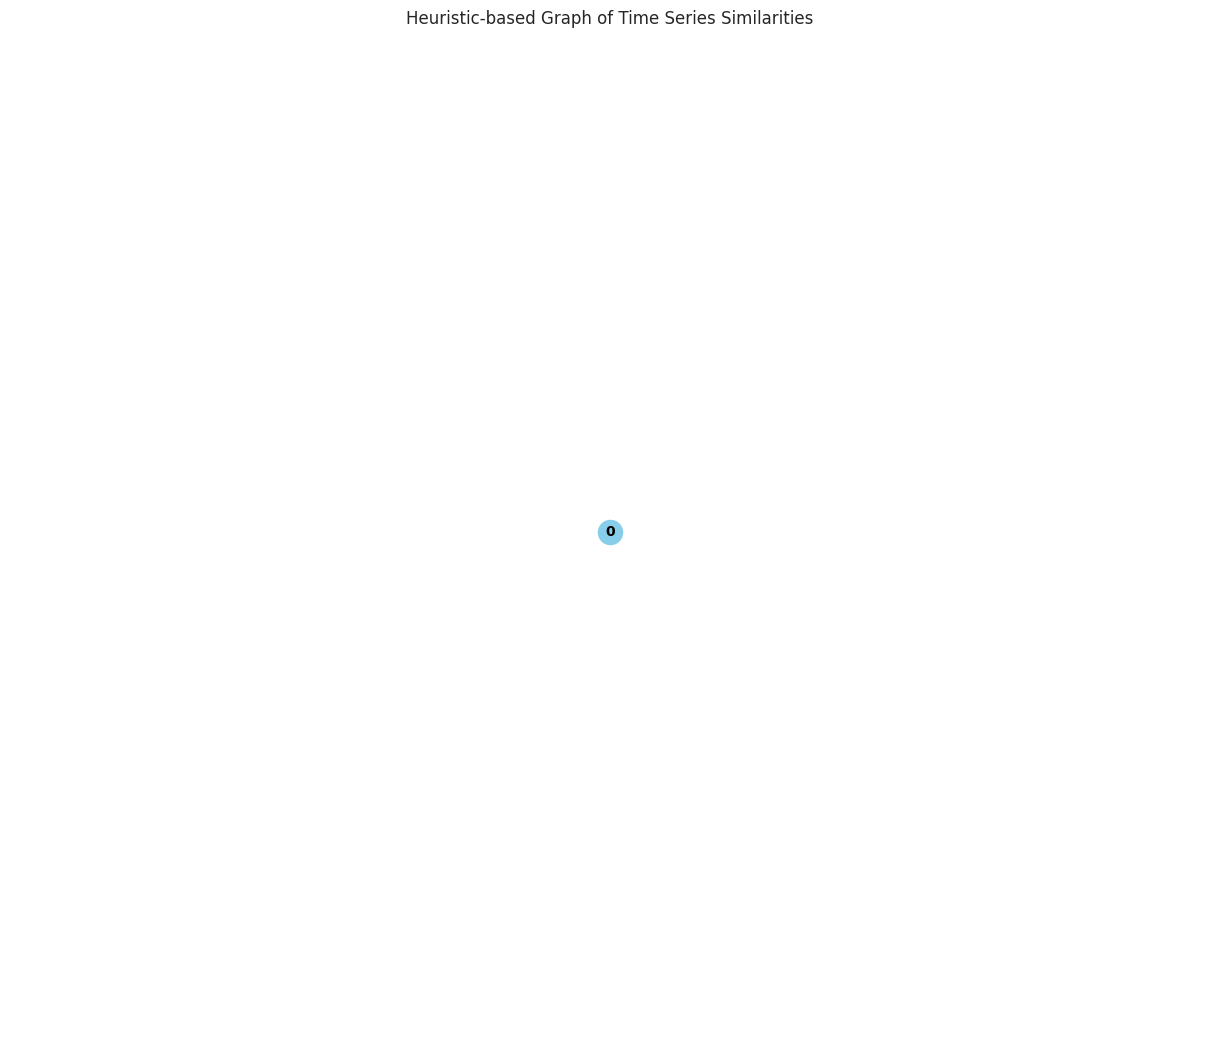

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('/kaggle/input/air-passenger-data-for-time-series-analysis/AirPassengers.csv')
data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)
time_series = data['#Passengers']

# For this example, let's create synthetic similar time series by shifting the data
time_series_data = [time_series.values]  # For simplicity, using one series
num_series = len(time_series_data)

# Generate pairwise correlation matrix
correlation_matrix = np.zeros((num_series, num_series))

# Compute pairwise correlations
for i in range(num_series):
    for j in range(i, num_series):
        if i != j:
            correlation = np.corrcoef(time_series_data[i], time_series_data[j])[0, 1]
            correlation_matrix[i, j] = correlation
            correlation_matrix[j, i] = correlation  # Symmetric matrix
        else:
            correlation_matrix[i, j] = 1  # Self-correlation is 1

# Convert correlations to similarities (e.g., scale from 0 to 1)
similarity_matrix = (correlation_matrix + 1) / 2  # Scale correlation to [0,1]

# Create a graph
G = nx.Graph()

# Add nodes
for i in range(num_series):
    G.add_node(i, label=f'Series {i}')

# Add edges with weights (using a similarity threshold to avoid too many edges)
threshold = 0.5
for i in range(num_series):
    for j in range(i + 1, num_series):
        weight = similarity_matrix[i, j]
        if weight > threshold:
            G.add_edge(i, j, weight=weight)

# Draw the graph
pos = nx.spring_layout(G, seed=42)  # Position nodes using the spring layout
weights = nx.get_edge_attributes(G, 'weight')

plt.figure(figsize=(12, 10))
nx.draw(G, pos, with_labels=True, node_size=300, node_color='skyblue', font_size=10, font_weight='bold', edge_color='gray')
nx.draw_networkx_edge_labels(G, pos, edge_labels=weights)
plt.title('Heuristic-based Graph of Time Series Similarities')
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances

# Load the dataset
data = pd.read_csv('/kaggle/input/air-passenger-data-for-time-series-analysis/AirPassengers.csv')
data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)
time_series = data['#Passengers']

# Create a DataFrame for features (mean and standard deviation in this case)
features = pd.DataFrame({
    'Mean': [np.mean(time_series)],
    'StdDev': [np.std(time_series)]
})

# For demonstration, let's assume we have multiple time series
# Create synthetic features for multiple series (using the same data for simplicity)
num_series = 10
feature_matrix = np.tile(features.values, (num_series, 1))

# Normalize features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(feature_matrix)


In [ ]:
# Compute pairwise Euclidean distances
distance_matrix = euclidean_distances(scaled_features)

# Convert distances to similarities (e.g., 1 / (1 + distance))
similarity_matrix = 1 / (1 + distance_matrix)


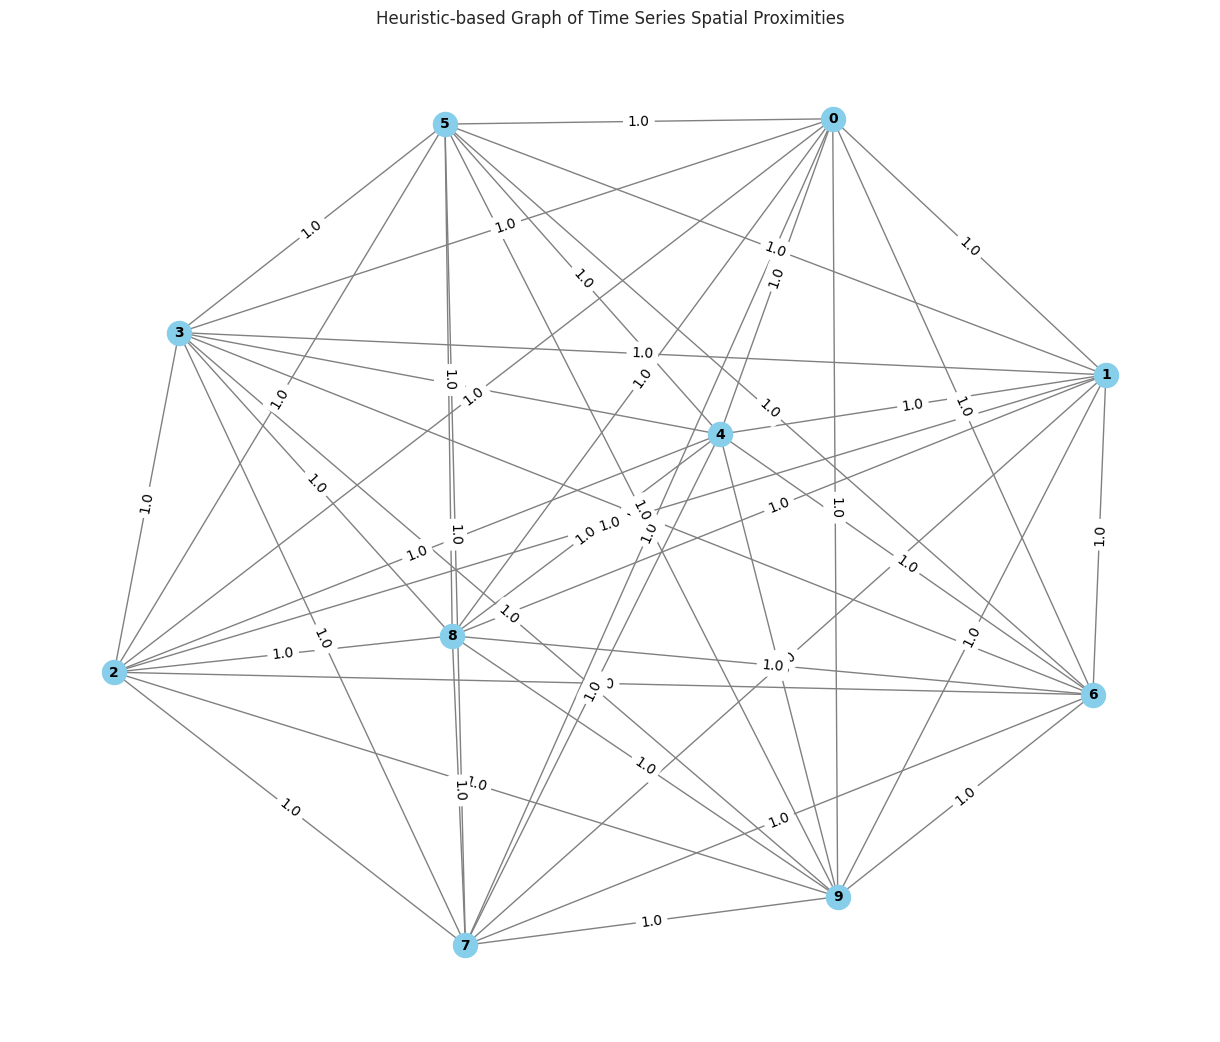

In [ ]:
# Create a graph
G = nx.Graph()

# Add nodes
for i in range(num_series):
    G.add_node(i, label=f'Series {i}')

# Add edges with weights (using a similarity threshold to avoid too many edges)
threshold = 0.5
for i in range(num_series):
    for j in range(i + 1, num_series):
        weight = similarity_matrix[i, j]
        if weight > threshold:
            G.add_edge(i, j, weight=weight)

# Draw the graph
pos = nx.spring_layout(G, seed=42)  # Position nodes using the spring layout
weights = nx.get_edge_attributes(G, 'weight')

plt.figure(figsize=(12, 10))
nx.draw(G, pos, with_labels=True, node_size=300, node_color='skyblue', font_size=10, font_weight='bold', edge_color='gray')
nx.draw_networkx_edge_labels(G, pos, edge_labels=weights)
plt.title('Heuristic-based Graph of Time Series Spatial Proximities')
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('/kaggle/input/air-passenger-data-for-time-series-analysis/AirPassengers.csv')
data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)
time_series = data['#Passengers']

# Create multiple time series (for demonstration, we will use the same series shifted)
num_series = 10
time_series_data = [time_series.shift(i).dropna() for i in range(num_series)]


In [ ]:
# Create a DataFrame where each column represents a time series
data_matrix = pd.DataFrame({f'Series_{i}': ts for i, ts in enumerate(time_series_data)})

# Compute pairwise correlation matrix
correlation_matrix = data_matrix.corr()

# Convert correlations to similarities (e.g., scale from 0 to 1)
similarity_matrix = (correlation_matrix + 1) / 2  # Scale correlation to [0,1]


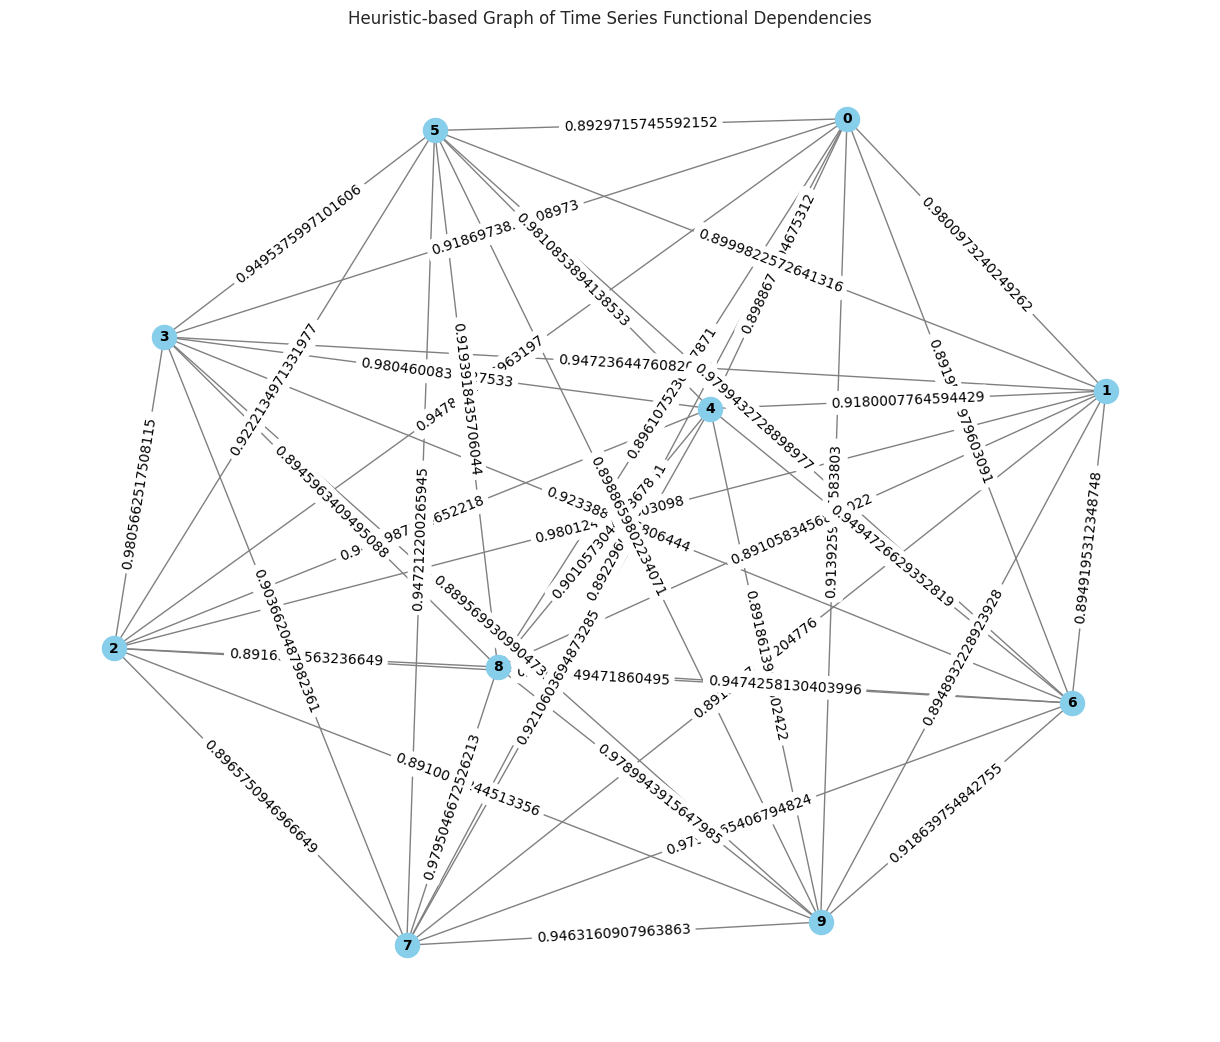

In [ ]:
# Create a graph
G = nx.Graph()

# Add nodes
for i in range(num_series):
    G.add_node(i, label=f'Series_{i}')

# Add edges with weights (using a similarity threshold to avoid too many edges)
threshold = 0.5
for i in range(num_series):
    for j in range(i + 1, num_series):
        weight = similarity_matrix.iloc[i, j]
        if weight > threshold:
            G.add_edge(i, j, weight=weight)

# Draw the graph
pos = nx.spring_layout(G, seed=42)  # Position nodes using the spring layout
weights = nx.get_edge_attributes(G, 'weight')

plt.figure(figsize=(12, 10))
nx.draw(G, pos, with_labels=True, node_size=300, node_color='skyblue', font_size=10, font_weight='bold', edge_color='gray')
nx.draw_networkx_edge_labels(G, pos, edge_labels=weights)
plt.title('Heuristic-based Graph of Time Series Functional Dependencies')
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances

# Load the dataset
data = pd.read_csv('/kaggle/input/air-passenger-data-for-time-series-analysis/AirPassengers.csv')
data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)
time_series = data['#Passengers']

# Create multiple time series (for demonstration, we will use the same series shifted)
num_series = 10
time_series_data = [time_series.shift(i).dropna() for i in range(num_series)]

# Create a DataFrame where each column represents a time series
data_matrix = pd.DataFrame({f'Series_{i}': ts for i, ts in enumerate(time_series_data)})

# Compute basic features (mean and standard deviation)
features = pd.DataFrame({
    'Mean': data_matrix.mean(),
    'StdDev': data_matrix.std()
}).T

# Generate pairwise distance matrix
feature_matrix = features.values
scaler = StandardScaler()
scaled_features = scaler.fit_transform(feature_matrix)
distance_matrix = euclidean_distances(scaled_features)

# Convert distances to similarities (e.g., 1 / (1 + distance))
similarity_matrix = 1 / (1 + distance_matrix)


In [ ]:
print(f"Shape of distance_matrix: {distance_matrix.shape}")
print(f"Shape of similarity_matrix: {similarity_matrix.shape}")


Shape of distance_matrix: (2, 2)
Shape of similarity_matrix: (2, 2)


Number of time series created: 10
Shape of distance_matrix: (10, 10)
Shape of similarity_matrix: (10, 10)


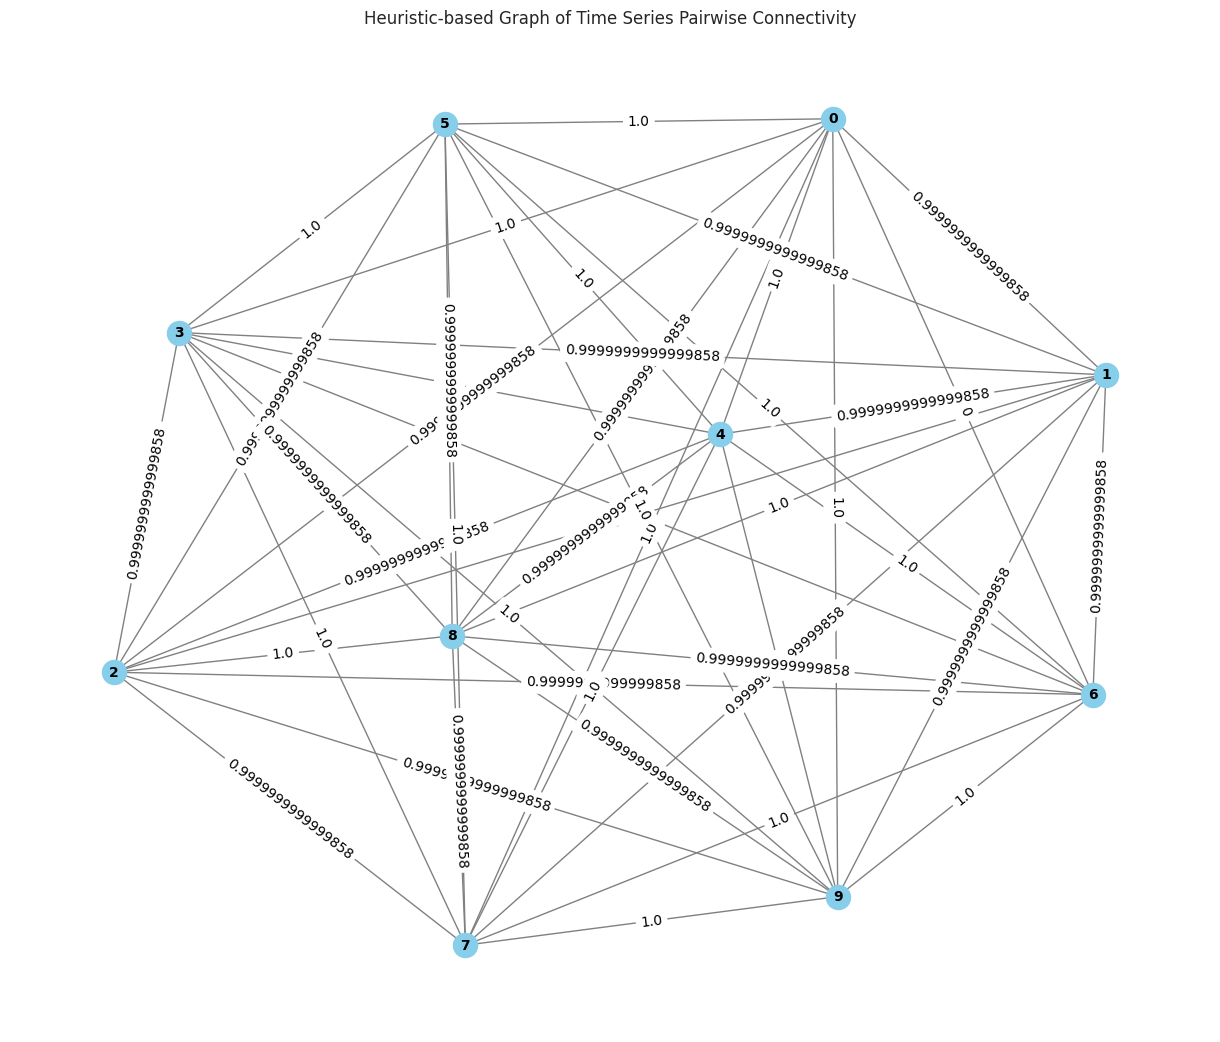

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances

# Load the dataset
data = pd.read_csv('/kaggle/input/air-passenger-data-for-time-series-analysis/AirPassengers.csv')
data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)
time_series = data['#Passengers']

# Create multiple time series (for demonstration, we will use the same series shifted)
num_series = 10
time_series_data = [time_series.shift(i).dropna() for i in range(num_series)]

# Check the number of time series created
print(f"Number of time series created: {len(time_series_data)}")

# Ensure each series has the same length
min_length = min(len(ts) for ts in time_series_data)
time_series_data = [ts[:min_length] for ts in time_series_data]  # Trim to the same length

# Create a DataFrame where each column represents a time series
data_matrix = pd.DataFrame({f'Series_{i}': ts for i, ts in enumerate(time_series_data)})

# Compute basic features (mean and standard deviation) for each time series
features = pd.DataFrame({
    'Mean': data_matrix.mean(),
    'StdDev': data_matrix.std()
})

# Generate pairwise distance matrix
feature_matrix = features.values
scaler = StandardScaler()
scaled_features = scaler.fit_transform(feature_matrix)
distance_matrix = euclidean_distances(scaled_features)

# Convert distances to similarities (e.g., 1 / (1 + distance))
similarity_matrix = 1 / (1 + distance_matrix)

# Verify shapes
print(f"Shape of distance_matrix: {distance_matrix.shape}")
print(f"Shape of similarity_matrix: {similarity_matrix.shape}")

# Create a graph
G = nx.Graph()

# Add nodes
for i in range(len(time_series_data)):
    G.add_node(i, label=f'Series_{i}')

# Add edges with weights (using a similarity threshold to avoid too many edges)
threshold = 0.5
for i in range(len(time_series_data)):
    for j in range(i + 1, len(time_series_data)):
        weight = similarity_matrix[i, j]
        if weight > threshold:
            G.add_edge(i, j, weight=weight)

# Draw the graph
pos = nx.spring_layout(G, seed=42)  # Position nodes using the spring layout
weights = nx.get_edge_attributes(G, 'weight')

plt.figure(figsize=(12, 10))
nx.draw(G, pos, with_labels=True, node_size=300, node_color='skyblue', font_size=10, font_weight='bold', edge_color='gray')
nx.draw_networkx_edge_labels(G, pos, edge_labels=weights)
plt.title('Heuristic-based Graph of Time Series Pairwise Connectivity')
plt.show()
